# New York City Yellow Taxi — Optimising Taxi Operations
### Exploratory Data Analysis · Prepared by Mudit Vyas


## Objective

This analysis explores the 2023 NYC Yellow Taxi trip records published by the NYC Taxi &
Limousine Commission (TLC) to find patterns that a new taxi operator could act on —
where demand concentrates, which zones drain supply, how pricing compares against
incumbent vendors, and what drives passenger tipping.


## Problem Statement

As an analyst at an upcoming taxi operation in NYC, the task is to use the 2023 taxi trip
data to uncover insights that could help optimise taxi operations. The goal is to analyse
patterns in the data that can inform strategic decisions to improve service efficiency,
maximise revenue, and enhance passenger experience.


## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation


### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.9.4
seaborn version: 0.13.2


### Paths and Configuration

In [4]:
# Paths are resolved relative to the repository root so this notebook runs
# anywhere it is cloned, on any operating system.
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
TAXI_ZONES_DIR = RAW_DIR / "taxi_zones"

# The twelve raw monthly files total ~1 GB and are not committed to the repository.
# Download them from the NYC TLC portal into this folder to re-run Section 1.
TRIP_RECORDS_DIR = RAW_DIR / "trip_records"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Fraction drawn from every hour-of-every-day when sampling the raw files.
SAMPLE_FRACTION = 0.01

print("Sampled dataset present:", (RAW_DIR / "df_sample_001.parquet").exists())
print("Raw monthly files present:",
      TRIP_RECORDS_DIR.exists() and any(TRIP_RECORDS_DIR.glob("*.parquet")))


Sampled dataset present: True
Raw monthly files present: False


### **1.1** Load the dataset


You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [5]:
# Try loading one file
monthly_file = TRIP_RECORDS_DIR / "2023-1.parquet"

if monthly_file.exists():
    df1 = pd.read_parquet(monthly_file)
    df1.info()
else:
    print(f"Raw monthly files not found in {TRIP_RECORDS_DIR.relative_to(PROJECT_ROOT)}.")
    print("Section 1 regenerates the sample from source; to just reproduce the")
    print("analysis, skip to Section 2 which loads the committed sample.")


Raw monthly files not found in data/raw/trip_records.
Section 1 regenerates the sample from source; to just reproduce the
analysis, skip to Section 2 which loads the committed sample.


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** Figure out how to sample and combine the files.


**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommended to not load all the files at once to avoid memory overload
if "df1" in dir():
    df1.info()
else:
    print("Raw monthly files unavailable - see the note above.")


Raw monthly files unavailable - see the note above.


In [7]:
# Sample every monthly file, stratified by date and hour.
# Source files are read from TRIP_RECORDS_DIR - no working-directory changes,
# so the notebook stays portable across machines.
file_list = sorted(TRIP_RECORDS_DIR.glob("*.parquet")) if TRIP_RECORDS_DIR.exists() else []

if not file_list:
    print(f"No monthly parquet files in {TRIP_RECORDS_DIR.relative_to(PROJECT_ROOT)}"
          " - skipping resampling.")

# initialise an empty dataframe
df3 = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_path in file_list:
    try:

        # Reading the current file
        df1= pd.read_parquet(file_path)
        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        df_df1_sample = pd.DataFrame()  
        # Loop through dates
        for unidate in df1.tpep_pickup_datetime.dt.date.unique():
            df1_date = df1[df1['tpep_pickup_datetime'].dt.date == unidate]
            sampled_data = pd.DataFrame()  # Initialize for each date
            # Iterate through each hour of the selected date
            for hr in df1_date.tpep_pickup_datetime.dt.hour.unique():
                df1_hour = df1_date[df1_date['tpep_pickup_datetime'].dt.hour == hr]
                # Sample 1% of the hourly data randomly
                df1_sample = df1_hour.sample(frac=SAMPLE_FRACTION, random_state=42) if not df1_hour.empty else pd.DataFrame()
                # Append sampled hourly data to the daily dataframe
                sampled_data = pd.concat([sampled_data, df1_sample], ignore_index=True)
            # Append sampled daily data to the final dataframe
            df_df1_sample = pd.concat([df_df1_sample, sampled_data], ignore_index=True)
        
        df3=pd.concat([df3,df_df1_sample],ignore_index=True)
    
    except Exception as e:
        print(f"Error reading file {file_path.name}: {e}")

No monthly parquet files in data/raw/trip_records - skipping resampling.


In [8]:
print(df3.shape if not df3.empty else "No data resampled (raw monthly files absent).")


No data resampled (raw monthly files absent).


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:
# Store the sampled data so the rest of the notebook can load it directly.
# Only parquet is written - the CSV equivalent is ~4x larger with no benefit.
if not df3.empty:
    df3.to_parquet(RAW_DIR / "df_sample_001.parquet", index=False)
    print(f"Wrote {len(df3):,} sampled trips to {RAW_DIR / 'df_sample_001.parquet'}")


## **2** Data Cleaning


Now we can load the new data directly.

In [10]:
# Load the sampled data file committed to the repository
sample_data = pd.read_parquet(RAW_DIR / "df_sample_001.parquet")
print(f"Loaded {len(sample_data):,} sampled trips")


Loaded 379,268 sampled trips


In [11]:
# df.head()
sample_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [12]:
# df.info()
sample_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379268 entries, 0 to 379267
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               379268 non-null  int64         
 1   tpep_pickup_datetime   379268 non-null  datetime64[us]
 2   tpep_dropoff_datetime  379268 non-null  datetime64[us]
 3   passenger_count        366326 non-null  float64       
 4   trip_distance          379268 non-null  float64       
 5   RatecodeID             366326 non-null  float64       
 6   store_and_fwd_flag     366326 non-null  object        
 7   PULocationID           379268 non-null  int64         
 8   DOLocationID           379268 non-null  int64         
 9   payment_type           379268 non-null  int64         
 10  fare_amount            379268 non-null  float64       
 11  extra                  379268 non-null  float64       
 12  mta_tax                379268 non-null  floa

#### **2.1** Fixing Columns
Fix/drop any columns as you seem necessary in the below sections


**2.1.1** Fix the index and drop unnecessary columns


In [13]:
# Fix the index and drop any columns that are not needed
sample_data = sample_data.reset_index(drop=True)

**2.1.2** There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.


In [14]:
# Combine the two airport fee columns
sample_data[['airport_fee','Airport_fee']] = sample_data[['airport_fee','Airport_fee']].fillna(0)
sample_data['airport_fee']= sample_data['airport_fee']+sample_data['Airport_fee']
sample_data=sample_data.drop(columns =['Airport_fee'])

**2.1.3** Fix columns with negative (monetary) values


In [15]:
# check where values of fare amount are negative
sample_data[sample_data.fare_amount<0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
sample_data.RatecodeID.unique()

array([ 1., nan,  2.,  5.,  3., 99.,  4.])

In [17]:
sample_data[(sample_data['RatecodeID'].isnull()) | (sample_data['RatecodeID']==99.)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379058,2,2023-09-30 19:45:46,2023-09-30 20:03:29,NaN,2.78,NaN,None,137,231,0,27.33,0.0,0.5,6.27,0.00,1.0,37.60,NaN,0.0
379068,2,2023-09-30 19:06:52,2023-09-30 19:26:11,NaN,1.93,NaN,None,239,230,0,20.02,0.0,0.5,0.00,0.00,1.0,24.02,NaN,0.0
379075,1,2023-09-30 19:40:22,2023-09-30 19:48:06,NaN,0.00,NaN,None,239,239,0,7.69,0.0,0.5,0.00,0.00,1.0,11.69,NaN,0.0
379138,1,2023-09-30 21:50:20,2023-09-30 22:06:38,NaN,0.00,NaN,None,249,87,0,19.71,0.0,0.5,0.00,0.00,1.0,23.71,NaN,0.0


In [18]:
# Find which columns have negative values
non_datetime_cols = sample_data.select_dtypes(exclude=['datetime', 'object']).columns
negative_rows = sample_data[sample_data[non_datetime_cols].lt(0).any(axis=1)]

# fix these negative values
for i in sample_data.select_dtypes(exclude=['datetime', 'object']).columns :
    sample_data[i] = sample_data[i].apply(lambda x: abs(x) if x<0 else x)

### **2.2** Handling Missing Values


**2.2.1**  Find the proportion of missing values in each column


In [19]:
# Find the proportion of missing values in each column
100.0*sample_data.isnull().sum()/ len(sample_data)


VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.412363
trip_distance            0.000000
RatecodeID               3.412363
store_and_fwd_flag       3.412363
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     3.412363
airport_fee              0.000000
dtype: float64

In [20]:
sample_data['passenger_count'].value_counts(normalize=True)

passenger_count
1.0    0.753719
2.0    0.150511
3.0    0.037431
4.0    0.020782
0.0    0.015898
5.0    0.012950
6.0    0.008694
8.0    0.000005
7.0    0.000005
9.0    0.000003
Name: proportion, dtype: float64

**2.2.2**  Handling missing values in `passenger_count`


In [21]:
# Display the rows with null values
sample_data[sample_data['passenger_count'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379058,2,2023-09-30 19:45:46,2023-09-30 20:03:29,NaN,2.78,NaN,None,137,231,0,27.33,0.0,0.5,6.27,0.00,1.0,37.60,NaN,0.0
379068,2,2023-09-30 19:06:52,2023-09-30 19:26:11,NaN,1.93,NaN,None,239,230,0,20.02,0.0,0.5,0.00,0.00,1.0,24.02,NaN,0.0
379075,1,2023-09-30 19:40:22,2023-09-30 19:48:06,NaN,0.00,NaN,None,239,239,0,7.69,0.0,0.5,0.00,0.00,1.0,11.69,NaN,0.0
379138,1,2023-09-30 21:50:20,2023-09-30 22:06:38,NaN,0.00,NaN,None,249,87,0,19.71,0.0,0.5,0.00,0.00,1.0,23.71,NaN,0.0


In [22]:
# Impute NaN values in 'passenger_count'
sample_data[sample_data.passenger_count.isnull()]
sample_data['passenger_count']= sample_data['passenger_count'].fillna(1)

In [23]:
sample_data['passenger_count'].value_counts(normalize=True)

passenger_count
1.0    0.762123
2.0    0.145375
3.0    0.036154
4.0    0.020073
0.0    0.015356
5.0    0.012508
6.0    0.008398
8.0    0.000005
7.0    0.000005
9.0    0.000003
Name: proportion, dtype: float64

Did you find zeroes in passenger_count? Handle these.

In [24]:
sample_data[sample_data.passenger_count == 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
87,1,2023-01-01 01:25:41,2023-01-01 01:25:45,0.0,0.0,1.0,N,148,148,1,3.0,3.5,0.5,52.00,0.0,1.0,60.00,2.5,0.0
162,1,2023-01-01 02:20:58,2023-01-01 02:31:32,0.0,1.5,1.0,Y,158,264,1,12.1,3.5,0.5,2.00,0.0,1.0,19.10,2.5,0.0
179,1,2023-01-01 02:31:22,2023-01-01 02:52:37,0.0,4.2,1.0,N,141,179,2,24.0,3.5,0.5,0.00,0.0,1.0,29.00,2.5,0.0
180,1,2023-01-01 02:19:56,2023-01-01 02:37:05,0.0,1.0,1.0,N,48,68,1,12.1,3.5,0.5,0.00,0.0,1.0,17.10,2.5,0.0
191,1,2023-01-01 03:11:25,2023-01-01 03:20:21,0.0,1.8,1.0,N,141,239,1,10.7,3.5,0.5,1.00,0.0,1.0,16.70,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379000,1,2023-09-30 18:44:47,2023-09-30 19:02:56,0.0,1.9,1.0,N,246,163,1,14.2,2.5,0.5,3.60,0.0,1.0,21.80,2.5,0.0
379011,1,2023-09-30 19:07:02,2023-09-30 19:13:38,0.0,1.4,1.0,N,239,142,1,9.3,2.5,0.5,2.65,0.0,1.0,15.95,2.5,0.0
379085,1,2023-09-30 20:12:49,2023-09-30 20:20:22,0.0,1.3,1.0,N,163,236,1,9.3,3.5,0.5,1.70,0.0,1.0,16.00,2.5,0.0
379116,1,2023-09-30 20:57:05,2023-09-30 21:31:44,0.0,3.7,1.0,N,107,256,1,26.1,3.5,0.5,0.00,0.0,1.0,31.10,2.5,0.0


In [25]:
sample_data = sample_data[sample_data['passenger_count']!=0]

sample_data['passenger_count'].value_counts(normalize=True)

passenger_count
1.0    0.774009
2.0    0.147642
3.0    0.036718
4.0    0.020386
5.0    0.012703
6.0    0.008529
8.0    0.000005
7.0    0.000005
9.0    0.000003
Name: proportion, dtype: float64

**2.2.3**  Handle missing values in `RatecodeID`


In [26]:
# Fix missing values in 'RatecodeID'
sample_data['RatecodeID'].value_counts(normalize=True)

RatecodeID
1.0     0.943959
2.0     0.039304
99.0    0.005903
5.0     0.005620
3.0     0.003223
4.0     0.001992
Name: proportion, dtype: float64

In [27]:
sample_data[sample_data['RatecodeID'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,1.0,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,1.0,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,1.0,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,1.0,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379058,2,2023-09-30 19:45:46,2023-09-30 20:03:29,1.0,2.78,NaN,None,137,231,0,27.33,0.0,0.5,6.27,0.00,1.0,37.60,NaN,0.0
379068,2,2023-09-30 19:06:52,2023-09-30 19:26:11,1.0,1.93,NaN,None,239,230,0,20.02,0.0,0.5,0.00,0.00,1.0,24.02,NaN,0.0
379075,1,2023-09-30 19:40:22,2023-09-30 19:48:06,1.0,0.00,NaN,None,239,239,0,7.69,0.0,0.5,0.00,0.00,1.0,11.69,NaN,0.0
379138,1,2023-09-30 21:50:20,2023-09-30 22:06:38,1.0,0.00,NaN,None,249,87,0,19.71,0.0,0.5,0.00,0.00,1.0,23.71,NaN,0.0


In [28]:
sample_data['RatecodeID']= sample_data['RatecodeID'].fillna(1)
sample_data['RatecodeID'].value_counts(normalize=True)

RatecodeID
1.0     0.945901
2.0     0.037941
99.0    0.005698
5.0     0.005425
3.0     0.003112
4.0     0.001923
Name: proportion, dtype: float64

**2.2.4**  Impute NaN in `congestion_surcharge`


In [29]:
# handle null values in congestion_surcharge
sample_data['congestion_surcharge'].value_counts(normalize=True)

congestion_surcharge
2.5    0.923473
0.0    0.076527
Name: proportion, dtype: float64

In [30]:
sample_data['congestion_surcharge']=sample_data['congestion_surcharge'].fillna(0)
sample_data['congestion_surcharge'].value_counts(normalize=True)

congestion_surcharge
2.5    0.89147
0.0    0.10853
Name: proportion, dtype: float64

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [31]:
# Handle any remaining missing values
sample_data['store_and_fwd_flag'].value_counts(normalize=True)

store_and_fwd_flag
N    0.99453
Y    0.00547
Name: proportion, dtype: float64

In [32]:
sample_data['store_and_fwd_flag']=sample_data['store_and_fwd_flag'].fillna('N')
sample_data['store_and_fwd_flag'].value_counts(normalize=True)

store_and_fwd_flag
N    0.994719
Y    0.005281
Name: proportion, dtype: float64

### **2.3** Handling Outliers


Before we start fixing outliers, let's perform outlier analysis.

In [33]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
sample_data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,373444.000000,373444,373444,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000,373444.000000
mean,1.745587,2023-07-02 23:53:22.344632,2023-07-03 00:10:45.017451,1.375783,3.625361,1.630068,165.219923,163.946535,1.162011,20.224596,1.556761,0.495386,3.549163,0.593449,0.999062,29.286409,2.228674,0.137829
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 18:42:23.500000,2023-04-02 18:59:53.500000,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-27 19:30:58,2023-06-27 19:49:41.500000,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-06 23:30:00,2023-10-06 23:46:49,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.890000,2.500000,0.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,4.000000,150.290000,143.000000,1.000000,143167.450000,2.500000,1.750000
std,0.441334,NaN,NaN,0.868259,49.772467,7.381344,64.034903,69.790316,0.506997,234.945861,1.813637,0.048248,4.031307,2.182347,0.028233,235.333980,0.777624,0.457135


**2.3.1**  Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.


How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [34]:
# remove passenger_count > 6
sample_data=sample_data[sample_data['passenger_count']<=6]

In [35]:
#distance is 0 but fare amount is not zero
sample_data[(sample_data['trip_distance']==0) & (sample_data['fare_amount']!= 0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
68,2,2023-01-01 01:34:06,2023-01-01 01:34:14,2.0,0.0,5.0,N,265,265,1,50.00,0.0,0.0,10.20,0.0,1.0,61.20,0.0,0.0
93,1,2023-01-01 01:26:38,2023-01-01 01:27:12,1.0,0.0,5.0,N,229,229,1,5.00,0.0,0.0,0.00,0.0,1.0,6.00,0.0,0.0
94,2,2023-01-01 01:20:00,2023-01-01 01:20:02,4.0,0.0,5.0,N,264,264,1,45.00,0.0,0.0,0.80,0.0,1.0,46.80,0.0,0.0
127,2,2023-01-01 23:14:50,2023-01-01 23:24:42,1.0,0.0,1.0,N,79,186,1,9.30,1.0,0.5,2.86,0.0,1.0,17.16,2.5,0.0
185,2,2023-01-01 03:18:36,2023-01-01 03:18:42,1.0,0.0,1.0,N,113,113,2,3.00,1.0,0.5,0.00,0.0,1.0,8.00,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379056,1,2023-09-30 19:11:23,2023-09-30 19:44:05,1.0,0.0,1.0,N,238,79,0,37.01,0.0,0.5,0.00,0.0,1.0,41.01,0.0,0.0
379075,1,2023-09-30 19:40:22,2023-09-30 19:48:06,1.0,0.0,1.0,N,239,239,0,7.69,0.0,0.5,0.00,0.0,1.0,11.69,0.0,0.0
379138,1,2023-09-30 21:50:20,2023-09-30 22:06:38,1.0,0.0,1.0,N,249,87,0,19.71,0.0,0.5,0.00,0.0,1.0,23.71,0.0,0.0
379215,1,2023-09-30 22:53:15,2023-09-30 23:10:04,1.0,0.0,1.0,N,48,249,0,21.88,0.0,0.5,0.00,0.0,1.0,25.88,0.0,0.0


In [36]:
#distance 0 , pickup and drop off location same by trip amount != 0
nr= sample_data[(sample_data['trip_distance']==0) & (sample_data['fare_amount']!= 0) & (sample_data['PULocationID']==sample_data['DOLocationID'])].index
sample_data= sample_data.drop(nr)

In [37]:
sample_data[(sample_data['trip_distance']==0) & (sample_data['fare_amount']!= 0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
127,2,2023-01-01 23:14:50,2023-01-01 23:24:42,1.0,0.0,1.0,N,79,186,1,9.30,1.0,0.5,2.86,0.00,1.0,17.16,2.5,0.0
269,1,2023-01-01 07:38:08,2023-01-01 08:12:08,1.0,0.0,1.0,N,159,228,1,47.20,0.0,0.5,0.00,0.00,1.0,48.70,0.0,0.0
434,1,2023-01-01 12:53:42,2023-01-01 13:21:04,1.0,0.0,1.0,N,130,41,1,42.50,0.0,0.5,0.00,6.55,1.0,50.55,0.0,0.0
502,2,2023-01-01 14:10:27,2023-01-01 14:30:57,1.0,0.0,1.0,N,264,161,1,17.00,0.0,0.5,4.20,0.00,1.0,25.20,2.5,0.0
749,1,2023-01-01 22:00:03,2023-01-01 22:05:42,1.0,0.0,1.0,N,79,113,0,6.00,1.0,0.5,1.65,0.00,1.0,14.65,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379008,1,2023-09-30 19:01:01,2023-09-30 19:19:12,1.0,0.0,1.0,N,137,249,0,15.10,0.0,0.5,0.00,0.00,1.0,19.10,0.0,0.0
379009,1,2023-09-30 19:12:45,2023-09-30 19:22:48,1.0,0.0,1.0,N,41,42,0,8.08,0.0,0.5,0.00,0.00,1.0,9.58,0.0,0.0
379056,1,2023-09-30 19:11:23,2023-09-30 19:44:05,1.0,0.0,1.0,N,238,79,0,37.01,0.0,0.5,0.00,0.00,1.0,41.01,0.0,0.0
379138,1,2023-09-30 21:50:20,2023-09-30 22:06:38,1.0,0.0,1.0,N,249,87,0,19.71,0.0,0.5,0.00,0.00,1.0,23.71,0.0,0.0


#### Trip distance more than 200 miles

In [38]:
# trip_distance more than 200 miles
sample_data[sample_data['trip_distance']>200]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
134003,2,2023-03-02 15:45:34,2023-03-02 16:00:45,1.0,9674.01,1.0,N,161,68,1,14.20,0.0,0.5,2.00,0.00,1.0,20.20,2.5,0.0
179495,2,2023-06-13 09:59:00,2023-06-13 10:12:00,1.0,22528.82,1.0,N,116,239,0,17.42,0.0,0.5,0.37,0.00,1.0,21.79,0.0,0.0
243196,2,2023-02-17 07:17:00,2023-02-17 07:25:00,1.0,8645.77,1.0,N,238,230,0,13.34,0.0,0.5,4.34,0.00,1.0,21.68,0.0,0.0
246117,2,2023-02-19 22:06:00,2023-02-19 22:22:00,1.0,6284.45,1.0,N,186,236,0,16.00,0.0,0.5,0.00,0.00,1.0,20.00,0.0,0.0
301827,2,2023-05-12 15:12:50,2023-05-12 16:03:58,1.0,9678.78,1.0,N,138,116,2,47.10,0.0,0.5,0.00,6.55,1.0,55.15,0.0,0.0
316456,2,2023-05-25 11:10:00,2023-05-25 11:35:00,1.0,10433.95,1.0,N,116,238,0,21.25,0.0,0.5,0.00,0.00,1.0,25.25,0.0,0.0


In [39]:
#drop those rows
sample_data=sample_data[sample_data['trip_distance']<=200]

#### Let's revisit trip distance and compare with fare amount

In [40]:
sample_data['trip_distance'].describe()

count    370449.000000
mean          3.473016
std           4.542667
min           0.000000
25%           1.070000
50%           1.800000
75%           3.420000
max         187.350000
Name: trip_distance, dtype: float64

<Axes: ylabel='trip_distance'>

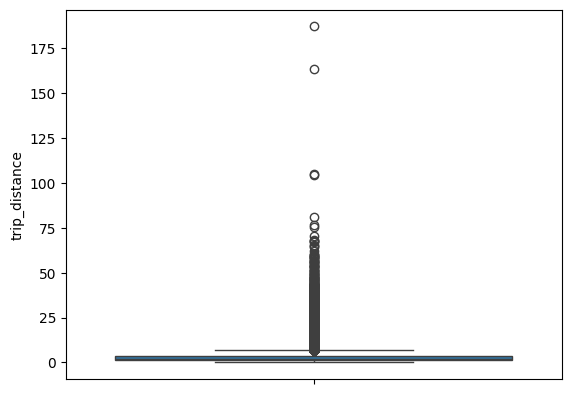

In [41]:
sns.boxplot(sample_data['trip_distance'])

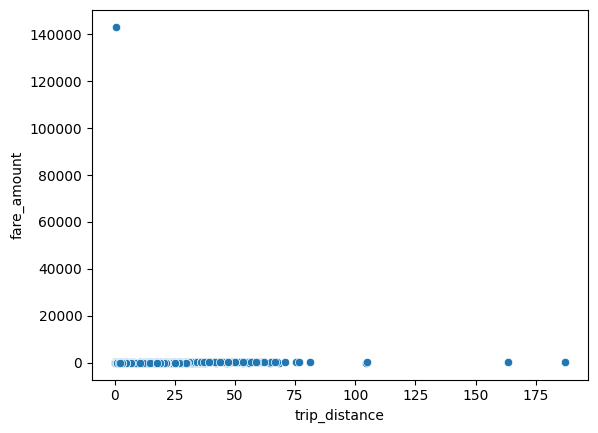

In [42]:
sns.scatterplot(data= sample_data, x='trip_distance',y='fare_amount')
plt.show()

In [43]:
sample_data = sample_data.drop(sample_data[sample_data['fare_amount']>20000].index)
sample_data =sample_data.drop(sample_data[sample_data['trip_distance']>100].index)

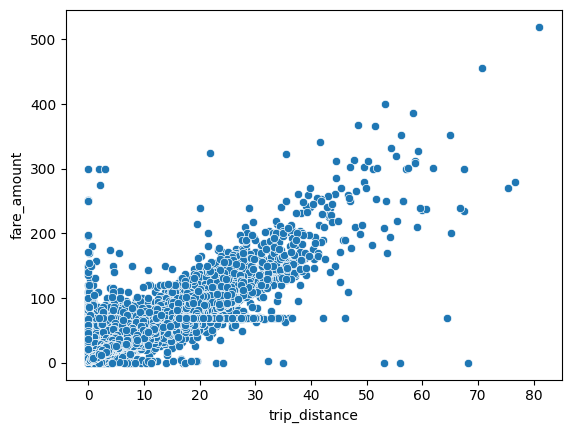

In [44]:
sns.scatterplot(data= sample_data, x='trip_distance',y='fare_amount')
plt.show()

In [45]:
sample_data[(sample_data['fare_amount']>400)]
#we are gonna keep these rows

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
124288,2,2023-12-22 13:20:04,2023-12-22 15:48:03,1.0,53.32,4.0,N,163,132,2,400.6,0.00,0.5,0.0,25.50,1.0,427.60,0.0,0.0
163551,2,2023-03-30 14:12:37,2023-03-30 16:44:19,2.0,81.03,4.0,N,132,265,2,519.6,1.25,0.0,0.0,8.21,1.0,530.06,0.0,0.0
244235,2,2023-02-18 17:22:37,2023-02-18 18:46:42,1.0,70.71,4.0,N,186,265,4,455.2,0.00,0.5,0.0,29.50,1.0,488.70,2.5,0.0


#### payment type = 0

In [46]:
sample_data['payment_type'].value_counts(normalize =True)

payment_type
1    0.790025
2    0.165326
0    0.034577
4    0.006703
3    0.003369
Name: proportion, dtype: float64

In [47]:
#let's drop the rows where both payment type and distance are zero
sample_data =sample_data.drop(sample_data[(sample_data['payment_type']==0) & (sample_data['trip_distance']==0)].index)

sample_data['payment_type'].value_counts(normalize =True)

payment_type
1    0.796070
2    0.166591
0    0.027190
4    0.006754
3    0.003395
Name: proportion, dtype: float64

In [48]:
#Let's check this approach - most used payment method is 1 and 2 , in ratio 5:1 .This method imputes the payment_type column , assigning payemnt type 1 and 2 in optimum ratio

sample_data = sample_data.reset_index(drop=True)
p_0 = sample_data[sample_data['payment_type']==0]
num = p_0.shape[0]

num_1= int(round(num*(5/6),0))
num_2=int(round(num*(1/6),0))

fill_values = np.array([1] * num_1 + [2] * num_2)
np.random.shuffle(fill_values)
sample_data.loc[p_0.index, 'payment_type'] = fill_values

sample_data['payment_type'].value_counts(normalize =True)

payment_type
1    0.818729
2    0.171123
4    0.006754
3    0.003395
Name: proportion, dtype: float64

#### mta_tax

In [49]:
sample_data['mta_tax'].unique()

array([0.5 , 0.  , 0.8 , 4.  , 0.05])

In [50]:
# simply replacing mta_tax to 0.5 wherever it's not 0.5

sample_data['mta_tax']= sample_data['mta_tax'].apply(lambda x : 0.5 if x in [0.8,0.05,4] else x)
sample_data['mta_tax'].describe()

count    367631.000000
mean          0.496608
std           0.041043
min           0.000000
25%           0.500000
50%           0.500000
75%           0.500000
max           0.500000
Name: mta_tax, dtype: float64

#### before we correct airport fee, we can observe calculation mismatch in total amount, let's look into it and fix it

In [51]:
sample_data['total_diff']= round(sample_data['total_amount']-(sample_data['fare_amount']+sample_data['extra']+sample_data['mta_tax']+sample_data['tip_amount']+sample_data['tolls_amount']+sample_data['improvement_surcharge']+sample_data['airport_fee']+sample_data['congestion_surcharge']),2)

sample_data['total_amount_actual']= sample_data['fare_amount']+sample_data['extra']+sample_data['mta_tax']+sample_data['tip_amount']+sample_data['tolls_amount']+sample_data['improvement_surcharge']+sample_data['airport_fee']+sample_data['congestion_surcharge']

sample_data['total_diff'].unique()

array([ 0.  ,  2.5 , -2.5 , -3.75, -1.25,  1.95, -0.3 , -4.25, -1.75,
        3.5 , -0.45,  4.5 ])

In [52]:
# Repair the fare components behind each recurring total_amount mismatch.
# Each difference maps to a specific missing or misapplied charge, so the components
# are corrected rather than the row being dropped.
#
# The masks are all evaluated against the original values before any assignment,
# which reproduces the row-wise if/elif exactly: every row takes at most one branch,
# and no row's condition depends on another row.
td = sample_data['total_diff']
cs = sample_data['congestion_surcharge']
af = sample_data['airport_fee']
mt = sample_data['mta_tax']

missing_congestion = ((td == 2.5) & (cs == 0)) | ((td == -2.5) & (cs == 2.5))
missing_both = ~missing_congestion & (td == -3.75)
airport_overcharged = ~missing_congestion & ~missing_both & (td == -0.5) & (af == 1.75)
airport_not_due = (~missing_congestion & ~missing_both & ~airport_overcharged
                   & (af == 1.75) & (td == -1.75))
missing_all_three = (~missing_congestion & ~missing_both & ~airport_overcharged
                     & ~airport_not_due & (mt == 0) & (td == -4.25))

sample_data.loc[missing_congestion, 'congestion_surcharge'] = cs[missing_congestion] + td[missing_congestion]
sample_data.loc[missing_both, ['congestion_surcharge', 'airport_fee']] = [2.5, 1.25]
sample_data.loc[airport_overcharged, 'airport_fee'] = 1.25
sample_data.loc[airport_not_due, 'airport_fee'] = 0
sample_data.loc[missing_all_three, ['mta_tax', 'congestion_surcharge', 'airport_fee']] = [0.5, 2.5, 1.25]

print(f"congestion surcharge restored : {missing_congestion.sum():>6,}")
print(f"congestion + airport fee      : {missing_both.sum():>6,}")
print(f"airport fee corrected to 1.25 : {airport_overcharged.sum():>6,}")
print(f"airport fee removed           : {airport_not_due.sum():>6,}")
print(f"mta + congestion + airport    : {missing_all_three.sum():>6,}")


congestion surcharge restored : 87,718
congestion + airport fee      :    973
airport fee corrected to 1.25 :      0
airport fee removed           :  1,947
mta + congestion + airport    :      6


In [53]:
sample_data['congestion_surcharge'].describe()

count    367631.000000
mean          1.781528
std           1.131363
min           0.000000
25%           0.000000
50%           2.500000
75%           2.500000
max           2.500000
Name: congestion_surcharge, dtype: float64

#### Outliers in Airport fee

In [54]:
sample_data['airport_fee'].value_counts(normalize= True)

airport_fee
0.00    0.920061
1.75    0.058629
1.25    0.021309
Name: proportion, dtype: float64

In [55]:
sample_data['airport_fee']= sample_data['airport_fee'].apply(lambda x : 1.25 if x==1.75 else x)
sample_data['airport_fee'].value_counts(normalize= True)

airport_fee
0.00    0.920061
1.25    0.079939
Name: proportion, dtype: float64

#### trip_distance is 0, trip_amount is not zero

In [56]:
# We finally drop such values, where trip distance is 0 and trip_amount is not zero
sample_data =sample_data.drop(sample_data[(sample_data['trip_distance']==0) & (sample_data['fare_amount']!=0)].index)

In [57]:
sample_data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,total_diff,total_amount_actual
count,366166.000000,366166,366166,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000,366166.000000
mean,1.752410,2023-07-02 08:10:14.274441,2023-07-02 08:27:42.897513,1.379063,3.512107,1.574395,165.281916,163.953933,1.197727,19.701180,1.577258,0.496772,3.578330,0.594159,0.999365,28.821048,1.784641,0.100159,-0.524273,29.345321
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.250000,0.000000
25%,2.000000,2023-04-02 09:40:28.250000,2023-04-02 09:52:44.500000,1.000000,1.100000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,16.000000,0.000000,0.000000,0.000000,16.630000
50%,2.000000,2023-06-26 16:56:56.500000,2023-06-26 17:12:45,1.000000,1.810000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.880000,0.000000,1.000000,21.000000,2.500000,0.000000,0.000000,21.800000
75%,2.000000,2023-10-06 11:24:38,2023-10-06 11:47:19.250000,1.000000,3.470000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.470000,0.000000,1.000000,30.720000,2.500000,0.000000,0.000000,31.400000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,6.000000,81.030000,99.000000,265.000000,265.000000,4.000000,519.600000,14.250000,0.500000,150.290000,86.000000,1.000000,530.060000,2.500000,1.250000,4.500000,530.060000
std,0.437583,NaN,NaN,0.871502,4.529517,7.084525,63.902573,69.749917,0.453190,17.705009,1.817272,0.040045,3.982427,2.166160,0.022260,22.348930,1.129895,0.339364,1.186678,22.348924


In [58]:
#recalculate total amount after fixing relavant columns
sample_data['total_amount_actual']= sample_data['fare_amount']+sample_data['extra']+sample_data['mta_tax']+sample_data['tip_amount']+sample_data['tolls_amount']+sample_data['improvement_surcharge']+sample_data['airport_fee']+sample_data['congestion_surcharge']

#### RatecodeID

In [59]:
sample_data['RatecodeID'].unique()

array([ 1.,  2.,  5.,  3., 99.,  4.])

In [60]:
sample_data['RatecodeID'].value_counts(normalize=True)

RatecodeID
1.0     0.949496
2.0     0.037685
99.0    0.005249
3.0     0.003010
5.0     0.002608
4.0     0.001953
Name: proportion, dtype: float64

In [61]:
sample_data['RatecodeID']=sample_data['RatecodeID'].replace(99,1)
sample_data['RatecodeID'].value_counts(normalize=True)

RatecodeID
1.0    0.954745
2.0    0.037685
3.0    0.003010
5.0    0.002608
4.0    0.001953
Name: proportion, dtype: float64

#### tip amount

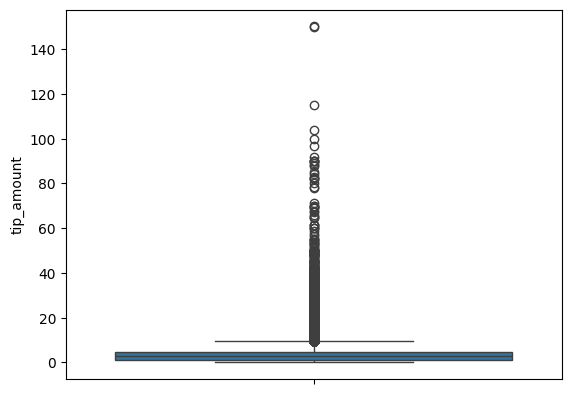

In [62]:
sns.boxplot(sample_data['tip_amount'])
plt.show()

In [63]:
sample_data[sample_data['tip_amount']>70]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,total_diff,total_amount_actual
35693,2,2023-10-06 18:50:39,2023-10-06 19:46:13,1.0,16.34,2.0,N,132,186,1,...,5.00,0.5,88.00,6.94,1.0,175.69,2.5,1.25,0.00,175.19
40782,2,2023-10-11 19:50:29,2023-10-11 21:11:21,1.0,65.05,4.0,N,132,265,1,...,2.50,0.0,78.64,36.69,1.0,473.58,0.0,1.25,0.00,473.08
41648,2,2023-10-13 06:22:27,2023-10-13 06:25:01,1.0,0.14,1.0,N,141,141,1,...,0.00,0.5,90.00,14.75,1.0,112.45,2.5,0.00,0.00,112.45
43996,2,2023-10-14 16:17:54,2023-10-14 17:05:53,2.0,16.55,1.0,N,132,145,1,...,0.00,0.5,78.07,6.94,1.0,156.36,0.0,1.25,0.00,155.86
54045,2,2023-10-23 19:32:12,2023-10-23 20:35:26,1.0,45.47,4.0,N,162,265,1,...,2.50,0.5,84.94,6.94,1.0,368.08,2.5,0.00,0.00,368.08
103687,2,2023-12-08 17:40:34,2023-12-08 19:18:35,1.0,54.45,4.0,N,162,265,1,...,2.50,0.5,103.84,6.94,1.0,449.98,2.5,0.00,0.00,449.98
107564,2,2023-12-11 22:28:48,2023-12-11 22:35:12,1.0,1.52,1.0,N,166,238,1,...,1.00,0.5,88.08,0.00,1.0,102.38,2.5,0.00,0.00,102.38
110095,2,2023-12-13 23:41:49,2023-12-14 00:19:59,1.0,17.28,2.0,N,132,229,1,...,0.00,0.5,82.00,6.94,1.0,164.69,2.5,1.25,0.00,164.19
110125,1,2023-12-13 23:03:21,2023-12-14 00:39:24,1.0,56.50,5.0,N,211,265,1,...,0.00,0.0,71.10,33.57,1.0,355.67,0.0,0.00,0.00,355.67
142155,2,2023-03-20 00:54:10,2023-03-20 01:26:46,1.0,21.96,2.0,N,132,261,1,...,0.00,0.5,80.00,0.00,1.0,155.25,2.5,1.25,0.00,155.25


In [64]:
sample_data = sample_data.drop(sample_data[(sample_data['tip_amount']>60) & (sample_data['trip_distance']<30) | (sample_data['tip_amount']>100)].index)

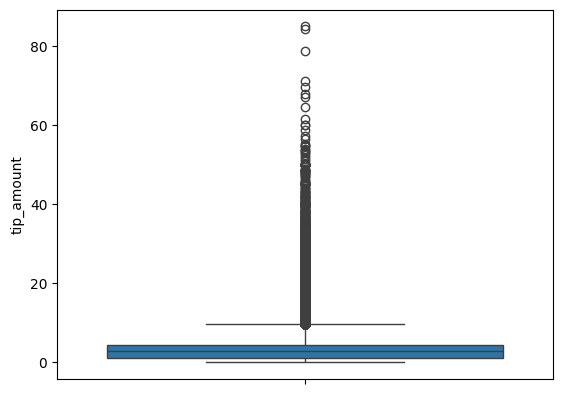

In [65]:
sns.boxplot(sample_data['tip_amount'])
plt.show()

In [66]:
# Do any columns need standardising?
None

## **3** Exploratory Data Analysis


In [67]:
sample_data.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'total_diff',
 'total_amount_actual']

#### **3.1** General EDA: Finding Patterns and Trends


**3.1.1** Categorise the varaibles into Numerical or Categorical.
* `VendorID`:Numerical
* `tpep_pickup_datetime`: Numerical
* `tpep_dropoff_datetime`: Numerical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical

The following monetary parameters belong in the same category, is it categorical or numerical?

Numerical
* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge` 
* `airport_fee`


##### Temporal Analysis

**3.1.2** Analyse the distribution of taxi pickups by hours, days of the week, and months.


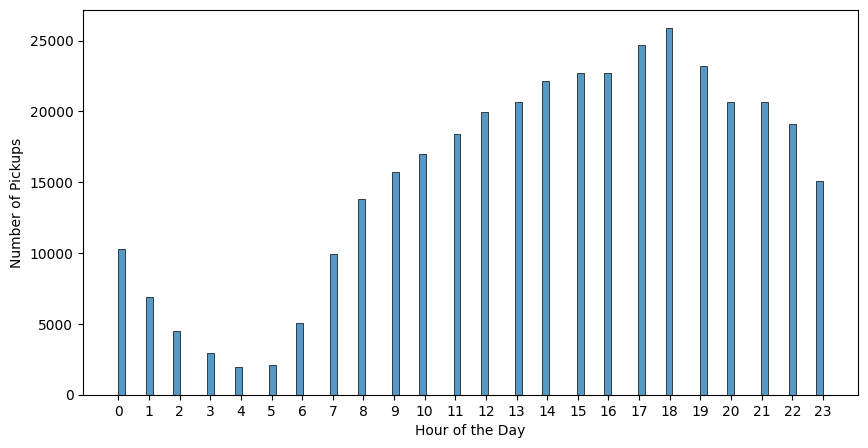

In [68]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(10,5))
sns.histplot(sample_data.tpep_pickup_datetime.dt.hour)
plt.xticks(range(24))
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.show()


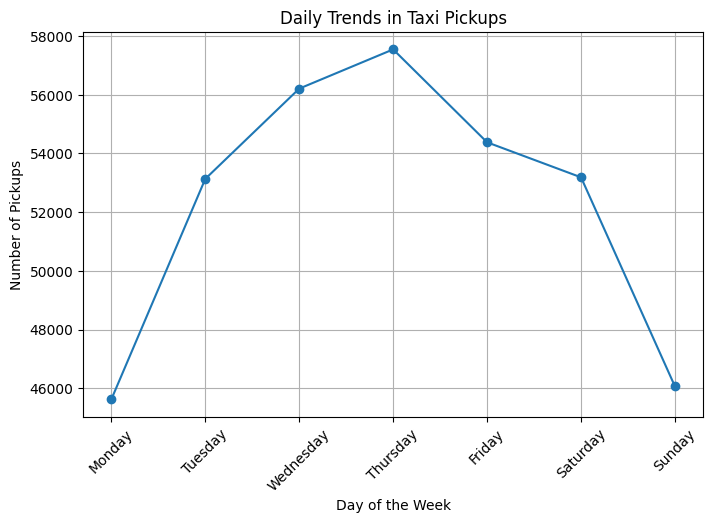

In [69]:
plt.figure(figsize=(8, 5))
# Extract day names directly and count them
daysi =['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
days = sample_data.tpep_pickup_datetime.dt.day_name()
plt.plot(days.value_counts().reindex(daysi,fill_value=0).index, days.value_counts().reindex(daysi,fill_value=0).values, marker='o', linestyle='-')

plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.title('Daily Trends in Taxi Pickups')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

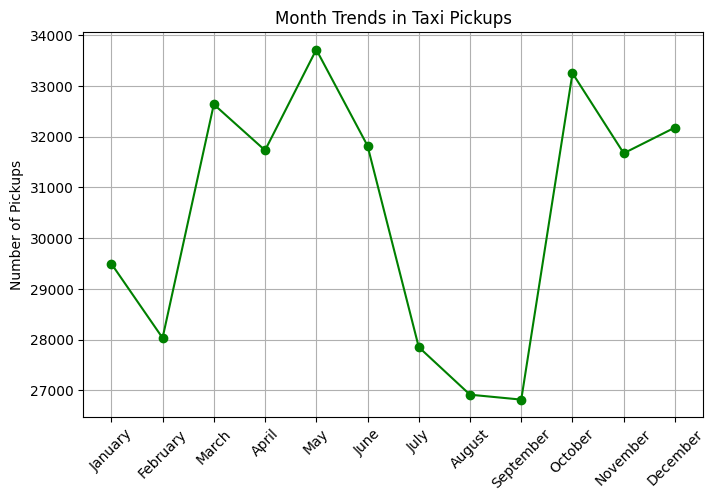

In [70]:
# Show the monthly trends in pickups

plt.figure(figsize=(8, 5))

# Extract month names directly and count them
monthi = ['January','February','March','April', 'May','June', 'July','August', 'September','October', 'November', 'December' ]
months = sample_data.tpep_pickup_datetime.dt.month_name()
plt.plot(months.value_counts().reindex(monthi,fill_value=0).index, months.value_counts().reindex(monthi,fill_value=0).values, marker='o', linestyle='-',color= 'green')

#plt.xlabel('Months')
plt.ylabel('Number of Pickups')
plt.title('Month Trends in Taxi Pickups')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [71]:
# Analyse the above parameters
sample_data[(sample_data['fare_amount']<=0) & (sample_data['tip_amount']<=0) & (sample_data['total_amount']<=0) & (sample_data['trip_distance']<=0)].shape

(35, 21)

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?


In [72]:
sample_data[(sample_data['PULocationID']==sample_data['DOLocationID']) & (sample_data['trip_distance']==0)].shape
#It is suitable to drop such rows

(44, 21)

In [73]:
# Create a df with non zero entries for the selected parameters.
sample_data =sample_data.drop(sample_data[(sample_data['fare_amount']<=0) & (sample_data['tip_amount']<=0) & (sample_data['total_amount']<=0) & (sample_data['trip_distance']<=0)].index)
sample_data = sample_data.drop(sample_data[(sample_data['PULocationID']==sample_data['DOLocationID']) & (sample_data['trip_distance']==0)].index)

**3.1.4** Analyse the monthly revenue (`total_amount`) trend


In [74]:
sample_data['total_amount'].groupby(sample_data.tpep_pickup_datetime.dt.month_name()).sum()

tpep_pickup_datetime
April        906317.07
August       780053.69
December     929522.37
February     766316.93
January      808040.08
July         801318.14
June         928832.88
March        918480.00
May          990087.95
November     916898.04
October      992059.08
September    810655.23
Name: total_amount, dtype: float64

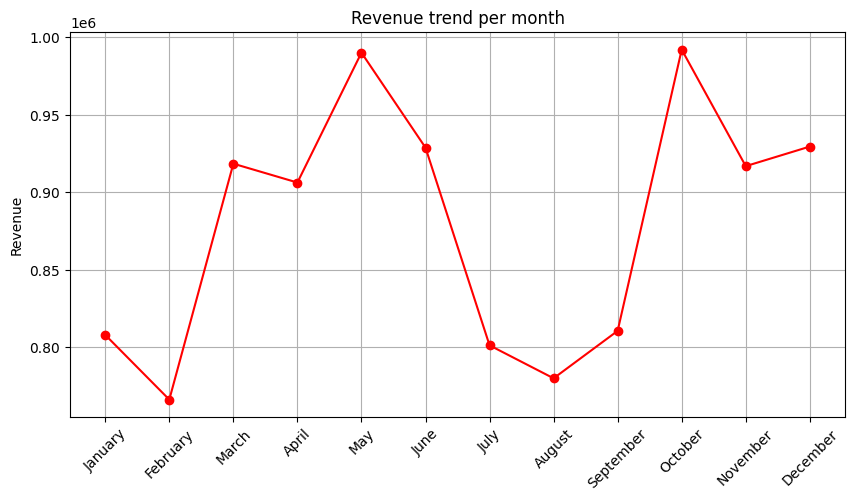

In [75]:
# Group data by month and analyse monthly revenue
# Show the monthly trends in pickups

plt.figure(figsize=(10, 5))

# Extract day names directly and count them
monthi = ['January','February','March','April', 'May','June', 'July','August', 'September','October', 'November', 'December' ]
revenue= sample_data['total_amount'].groupby(sample_data.tpep_pickup_datetime.dt.month_name()).sum()
plt.plot(revenue.reindex(monthi,fill_value=0).index,revenue.reindex(monthi,fill_value=0).values, marker='o', linestyle='-',color= 'red')

#plt.xlabel('Months')
plt.ylabel('Revenue')
plt.title('Revenue trend per month')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.grid(True)

plt.show()

**3.1.5** Show the proportion of each quarter of the year in the revenue


In [76]:
# Calculate proportion of each quarter
sample_data['total_amount'].groupby(sample_data.tpep_pickup_datetime.dt.quarter).sum()


tpep_pickup_datetime
1    2492837.01
2    2825237.90
3    2392027.06
4    2838479.49
Name: total_amount, dtype: float64

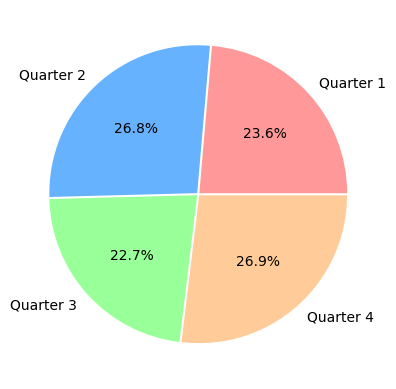

In [77]:
revenue_quarter = sample_data['total_amount'].groupby(sample_data.tpep_pickup_datetime.dt.quarter).sum()

labels=['Quarter 1','Quarter 2','Quarter 3','Quarter 4']
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
explode = [0.01,0.01,0.01,0.01]
plt.pie(revenue_quarter.values, labels=labels,explode=explode, autopct='%1.1f%%',colors=colors)
plt.show()

**3.1.6** Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0


In [78]:
sample_data['trip_distance'].corr(sample_data['fare_amount'])

0.9445082863468623

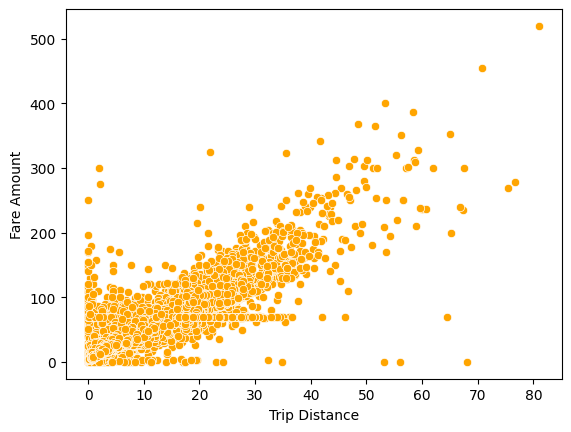

In [79]:
# Show how trip fare is affected by distance
sns.scatterplot(data=sample_data[sample_data['trip_distance']!=0], x= 'trip_distance',y= 'fare_amount',color = 'orange')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.show()


**3.1.7** Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`


<Axes: >

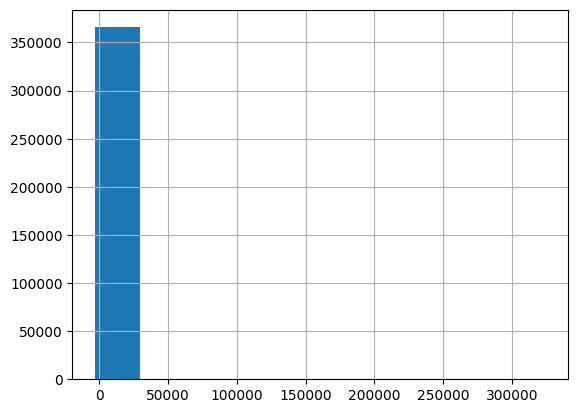

In [80]:
# Show relationship between fare and trip duration
sample_data['trip_duration']= sample_data['tpep_dropoff_datetime']- sample_data['tpep_pickup_datetime']
sample_data['trip_duration'] =sample_data['trip_duration'].dt.total_seconds()
sample_data['trip_duration'].hist()

In [81]:
sample_data =sample_data[sample_data['trip_duration']<300000]
sample_data['trip_duration'].corr(sample_data['fare_amount'])

0.2865375438333969

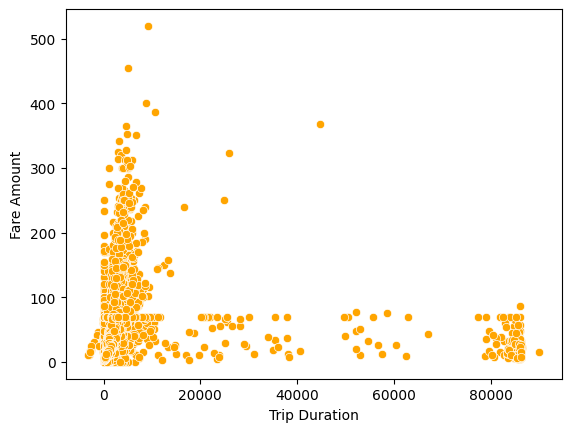

In [82]:
sns.scatterplot(data= sample_data, x= 'trip_duration',y= 'fare_amount', color='orange')
plt.xlabel('Trip Duration')
plt.ylabel('Fare Amount')
plt.show()

In [83]:
# Show relationship between fare and number of passengers
sample_data['fare_amount'].corr(sample_data['passenger_count'])

0.038943968784383116

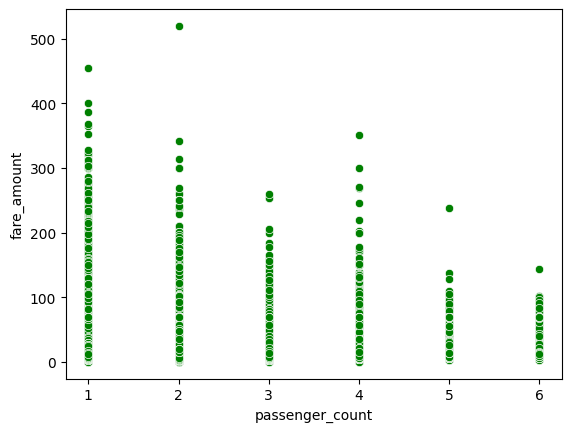

In [84]:
sns.scatterplot(data= sample_data, x= 'passenger_count',y= 'fare_amount', color='green')
plt.show()

In [85]:
# Show relationship between tip and trip distance
sample_data['tip_amount'].corr(sample_data['trip_distance'])

0.5981232973123315

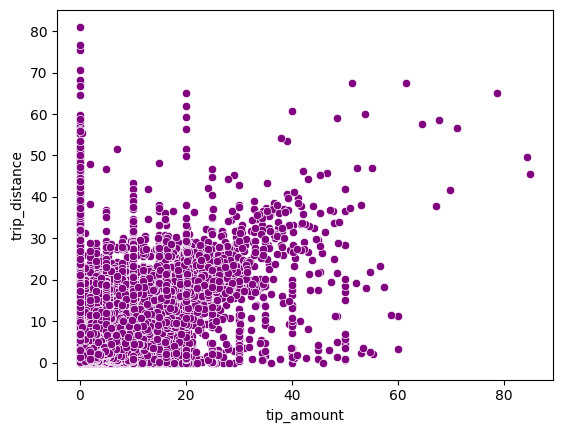

In [86]:
sns.scatterplot(data= sample_data, x= 'tip_amount',y= 'trip_distance', color='purple')
plt.show()

**3.1.8** Analyse the distribution of different payment types (`payment_type`)


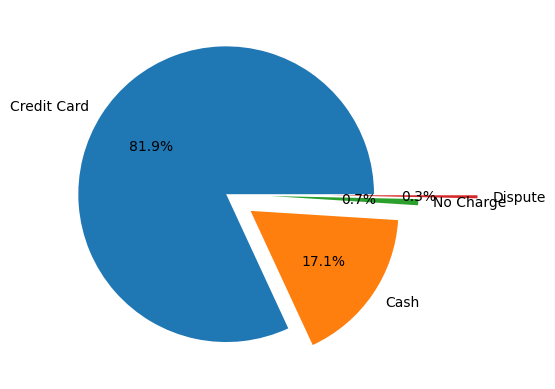

In [87]:
# Analyse the distribution of different payment types (payment_type).
payment = sample_data['payment_type'].value_counts()
labels=['Credit Card','Cash','No Charge','Dispute']
explode = [0.0,0.2,0.3,0.7]
plt.pie(payment.values, labels=labels,explode=explode,autopct='%1.1f%%')
plt.show()

##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

**3.1.9** Load the shapefile and display it.


In [88]:
import geopandas as gpd

# Read the shapefile using geopandas. The .shp needs its sibling files
# (.dbf, .shx, .prj ...) present in the same folder to open.
zones = gpd.read_file(TAXI_ZONES_DIR / "taxi_zones.shp")
zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

<Figure size 1000x800 with 0 Axes>

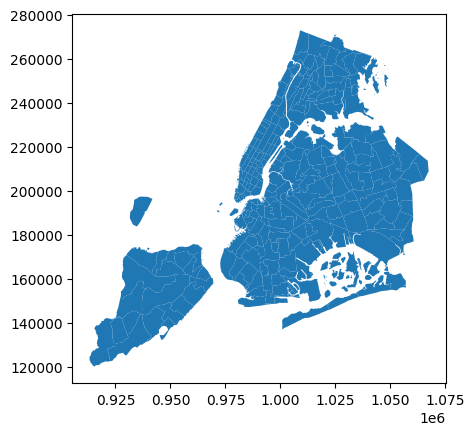

In [89]:
print(zones.info())
plt.figure(figsize=(10,8))
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** Merge the zones data into trip data using the `locationID` and `PULocationID` columns.


In [90]:
# Merge zones and trip records using locationID and PULocationID
sample_data2= pd.merge(sample_data,zones,left_on='PULocationID',right_on='LocationID')

**3.1.11** Group data by location IDs to find the total number of trips per location ID


In [91]:
# Group data by location and calculate the number of trips
location_trips =pd.DataFrame(sample_data2['LocationID'].value_counts()).reset_index()

**3.1.12** Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.


In [92]:
# Merge trip counts back to the zones GeoDataFrame
zones= pd.merge(zones,location_trips, left_on ='LocationID',right_on = 'LocationID')

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** Plot a color-coded map showing zone-wise trips


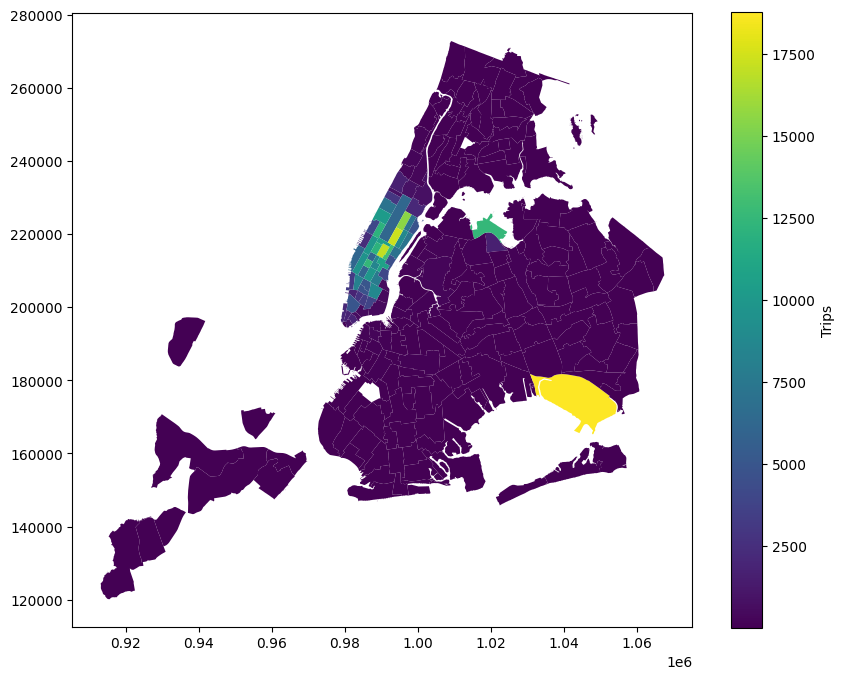

In [93]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (10, 8))

# Plot the map and display it
zones.plot(column = 'count',ax=ax,legend=True,legend_kwds ={'label': "Trips", 'orientation': "vertical"} )
plt.show()

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


### Findings from the General Analysis

**Busiest hours, days and months.** Pickups build through the afternoon and peak at **6 PM**,
with the five busiest hours all falling between 3 PM and 7 PM. Scaled back up by the 1%
sampling fraction, 6 PM alone accounts for roughly **2.56 million trips** across the year.
Weekdays show the classic commuter double-peak; weekends start later and hold a much
stronger post-midnight tail. October and May are the heaviest months, February the lightest.

**Trends in revenue collected.** Monthly revenue tracks trip volume closely, ranging from
**$766K in February to $992K in October** in the sample — a spread of about 29%. There is
no dramatic seasonality, but the winter trough is consistent across January and February.

**Trends in quarterly revenue.** Revenue is spread more evenly than expected:
**Q1 23.6%, Q2 26.8%, Q3 22.7%, Q4 26.9%**. Q3 is the weakest quarter despite summer
tourism, likely reflecting residents leaving the city in August.

**How fare depends on distance, duration and passenger count.** Distance is overwhelmingly
the driver of fare (**r = 0.94**). Trip duration correlates far more weakly (**r = 0.29**),
which tells us the meter is distance-led rather than time-led and that time spent in traffic
is largely unpaid. Passenger count is effectively irrelevant to fare (**r = 0.04**) — the
meter does not price per head.

**How tip amount depends on trip distance.** Tips rise with distance at a moderate
**r = 0.60** — weaker than the fare relationship, because tipping is percentage-based
and that percentage actually *falls* slightly on longer trips.

**Busiest zones.** Pickups concentrate at **JFK Airport (782 average hourly pickups),
Upper East Side South (720) and Midtown Center (709)**. Drop-offs shift residential —
**Upper East Side North (681)** and **Upper East Side South (645)** lead. The gap between
those two lists is the operationally interesting part: the airports generate far more
departures than arrivals by taxi, so cabs must be fed into them deliberately.

**Payment and occupancy mix.** **81.9% of trips are paid by credit card** and 17.1% by cash;
because cash tips are never recorded, true tipping is understated throughout. **77.4% of
trips carry a single passenger**, and 95.5% run on the standard rate code.


#### **3.2** Detailed EDA: Insights and Strategies


Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.


Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [94]:
# Find routes which have the slowest speeds at different times of the day
sample_data2['speed']= sample_data2['trip_distance']/(sample_data2['trip_duration']/3600)
sample_data2=sample_data2.drop(sample_data2[sample_data2['tpep_pickup_datetime']> sample_data2['tpep_dropoff_datetime']].index)

min_speed= pd.DataFrame(sample_data2.groupby([sample_data2.tpep_pickup_datetime.dt.hour,'LocationID' ])['speed'].mean().reset_index().sort_values(by=['tpep_pickup_datetime','speed'],ascending=[True,True]))
min_speed['rownum']= min_speed.groupby('tpep_pickup_datetime').cumcount()+1
min_speed=min_speed.rename(columns ={'tpep_pickup_datetime':'Hour'})
min_speed[min_speed['rownum']==1]

,Hour,LocationID,speed,rownum
47,0,116,7.292450,1
155,1,134,7.769784,1
237,2,89,0.303030,1
330,3,82,8.325188,1
411,4,18,1.199001,1
631,5,219,0.882137,1
698,6,70,0.085750,1
875,7,128,0.115385,1
1048,8,134,1.106331,1
1308,9,257,1.487603,1


How does identifying high-traffic, high-demand routes help us?

**3.2.2** Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.


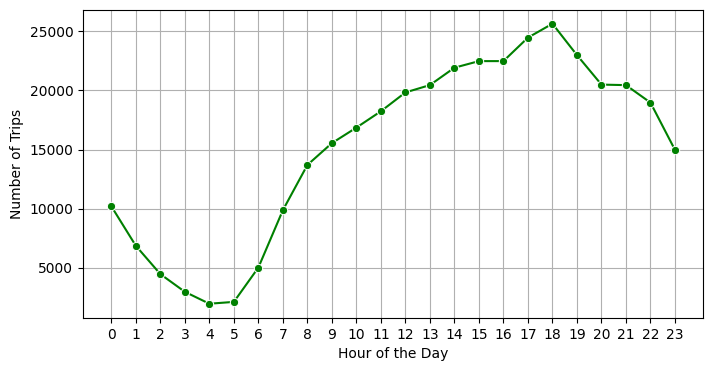

In [95]:
# Visualise the number of trips per hour and find the busiest hour
hour_rides = sample_data2.tpep_pickup_datetime.dt.hour.value_counts().sort_index()
plt.figure(figsize=(8,4))
sns.lineplot(x= hour_rides.index, y= hour_rides.values,marker='o',color ='green')
plt.xticks(range(24))
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.grid(True)
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** Find the actual number of trips in the five busiest hours


In [96]:
# Scale up the number of trips
# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.01
(sample_data2.tpep_pickup_datetime.dt.hour.value_counts()/sample_fraction).astype(int).head(5)

tpep_pickup_datetime
18    2564600
17    2446800
19    2299100
16    2248200
15    2248000
Name: count, dtype: int64

**3.2.4** Compare hourly traffic pattern on weekdays. Also compare for weekend.


<Figure size 1000x500 with 0 Axes>

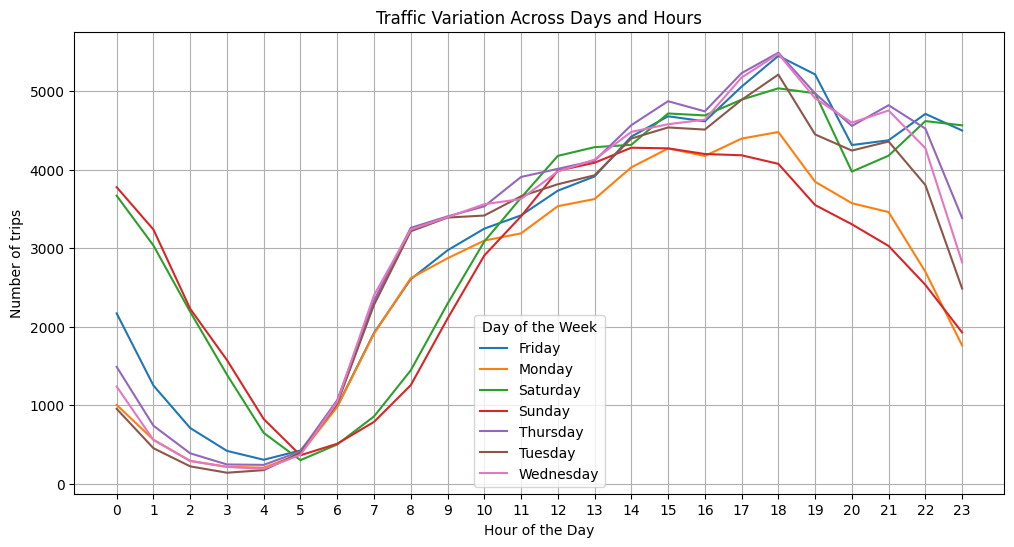

In [97]:
# Compare traffic trends for the week days and weekends
plt.figure(figsize=(10, 5))

sample_data2.groupby([ sample_data2['tpep_pickup_datetime'].dt.hour,sample_data2['tpep_pickup_datetime'].dt.day_name()])['passenger_count'].sum().unstack().plot(kind='line', figsize=(12, 6))
plt.title('Traffic Variation Across Days and Hours')
plt.xticks(sample_data2['tpep_pickup_datetime'].dt.hour.unique())
plt.xlabel('Hour of the Day')
plt.ylabel('Number of trips')
plt.legend(title='Day of the Week')
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.


In [98]:
# Find top 10 pickup and dropoff zones
pickup=pd.DataFrame(sample_data2.groupby(['PULocationID',sample_data2.tpep_pickup_datetime.dt.hour])['PULocationID'].value_counts().reset_index())

pickup_hour_top10= pickup.groupby('PULocationID')['count'].mean().sort_values(ascending=False).head(10).reset_index()

zone_pickup_top10= pd.merge(pickup_hour_top10,zones, how ='left',left_on ='PULocationID', right_on ='LocationID')
zone_pickup_top10=zone_pickup_top10.rename(columns = {'count_x': 'Avg hourly pickup'})
zone_pickup_top10[['zone','Avg hourly pickup']]

,zone,Avg hourly pickup
0,JFK Airport,782.041667
1,Upper East Side South,720.500000
2,Midtown Center,708.875000
3,Upper East Side North,647.000000
4,Midtown East,545.625000
5,LaGuardia Airport,522.250000
6,Penn Station/Madison Sq West,519.166667
7,Lincoln Square East,504.000000
8,Times Sq/Theatre District,503.291667
9,Murray Hill,450.625000


In [99]:
dropoff=pd.DataFrame(sample_data2.groupby(['DOLocationID',sample_data2.tpep_dropoff_datetime.dt.hour])['DOLocationID'].value_counts().reset_index())

dropoff_hour_top10= dropoff.groupby('DOLocationID')['count'].mean().sort_values(ascending=False).head(10).reset_index()

zone_dropoff_top10= pd.merge(dropoff_hour_top10,zones, how ='left',left_on ='DOLocationID', right_on ='LocationID')
zone_dropoff_top10=zone_dropoff_top10.rename(columns = {'count_x': 'Avg hourly dropoff'})
zone_dropoff_top10[['zone','Avg hourly dropoff']]

,zone,Avg hourly dropoff
0,Upper East Side North,680.541667
1,Upper East Side South,644.875000
2,Midtown Center,596.416667
3,Times Sq/Theatre District,462.791667
4,Murray Hill,453.333333
5,Midtown East,434.000000
6,Lincoln Square East,430.791667
7,Upper West Side South,423.875000
8,Lenox Hill West,400.208333
9,East Chelsea,389.041667


**3.2.6** Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.


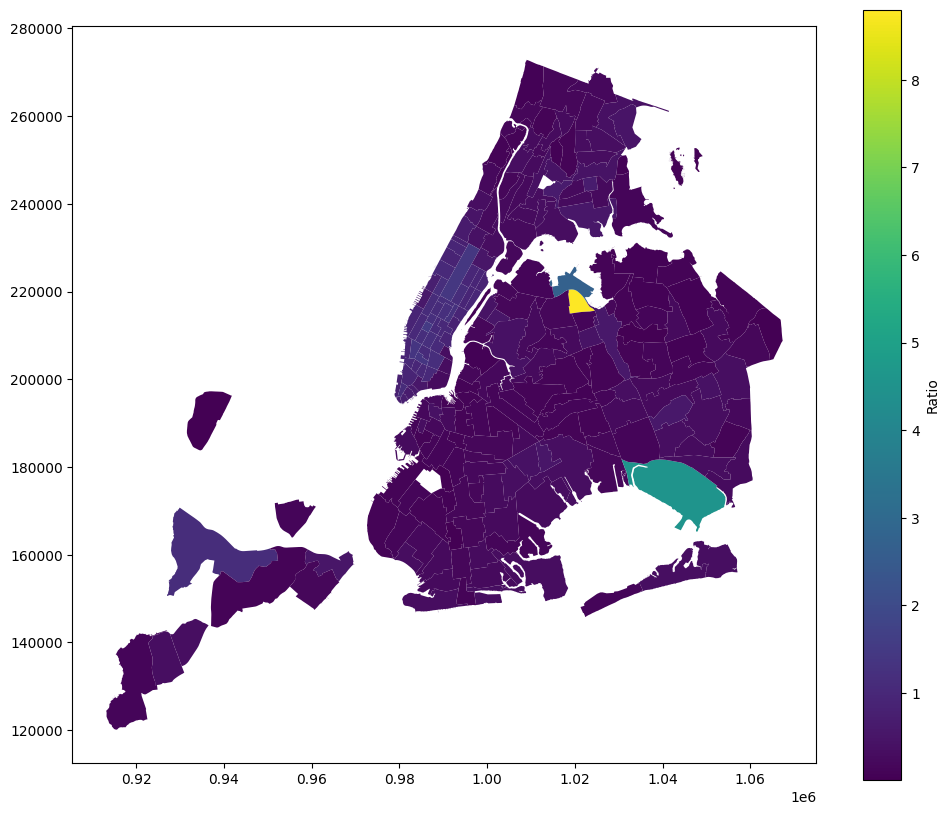

In [100]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_num= pd.DataFrame(sample_data2['PULocationID'].value_counts().reset_index())
pickup_num

dropoff_num = pd.DataFrame(sample_data2['DOLocationID'].value_counts().reset_index())
dropoff_num

pickup_dropoff = pd.merge(pickup_num,dropoff_num,left_on='PULocationID',right_on='DOLocationID',suffixes=['_PU','_DO'])
pickup_dropoff['PU_DO_ratio']= round(pickup_dropoff['count_PU']/pickup_dropoff['count_DO'],2)
pickup_dropoff=pickup_dropoff.sort_values(by=['PU_DO_ratio'],ascending=False)

pickup_dropoff
zone_pu_do = pd.merge(zones, pickup_dropoff, how='left', left_on='LocationID',right_on ='PULocationID')

fig, ax = plt.subplots(1, 1, figsize = (12, 10))
zone_pu_do.plot(column = 'PU_DO_ratio',ax=ax,legend=True,legend_kwds ={'label': "Ratio", 'orientation': "vertical"} )
plt.show()

In [101]:
zone_pu_do=zone_pu_do.sort_values(by='PU_DO_ratio',ascending=False)

zone_pu_do[['zone','PU_DO_ratio']].head(10)

,zone,PU_DO_ratio
63,East Elmhurst,8.80
116,JFK Airport,4.56
122,LaGuardia Airport,2.69
166,Penn Station/Madison Sq West,1.53
38,Central Park,1.39
225,West Village,1.36
99,Greenwich Village South,1.36
145,Midtown East,1.26
144,Midtown Center,1.19
210,Union Sq,1.19


In [102]:
zone_pu_do[['zone','PU_DO_ratio']].tail(10)

,zone,PU_DO_ratio
180,Roosevelt Island,0.06
97,Greenpoint,0.06
90,Fresh Meadows,0.06
227,Whitestone,0.05
93,Glendale,0.05
232,Windsor Terrace,0.03
92,Glen Oaks,0.03
159,Ocean Parkway South,0.03
171,Queensboro Hill,0.02
0,Newark Airport,0.01


**3.2.7** Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)


In [103]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_rides = sample_data2[ (sample_data2['tpep_pickup_datetime'].dt.time >= pd.to_datetime('23:00:00').time()) | (sample_data2['tpep_pickup_datetime'].dt.time < pd.to_datetime('05:00:00').time())]

pickup_num_night= pd.DataFrame(night_rides['PULocationID'].value_counts().reset_index())
dropoff_num_night = pd.DataFrame(night_rides['DOLocationID'].value_counts().reset_index())


pickup_dropoff_night = pd.merge(pickup_num_night,dropoff_num_night,left_on='PULocationID',right_on='DOLocationID',suffixes=['_PU','_DO'])
pickup_dropoff_night['PU_DO_ratio']= round(pickup_dropoff_night['count_PU']/pickup_dropoff_night['count_DO'],2)
pickup_dropoff_night=pickup_dropoff_night.sort_values(by=['PU_DO_ratio'],ascending=False)

pickup_dropoff_night = pd.merge(pickup_dropoff_night,zones, how='left', left_on ='PULocationID', right_on ='LocationID')

pickup_dropoff_night[['zone','PU_DO_ratio']].head(10)

,zone,PU_DO_ratio
0,JFK Airport,11.12
1,East Elmhurst,6.62
2,LaGuardia Airport,5.42
3,Greenwich Village South,3.48
4,West Village,2.76
5,Flushing Meadows-Corona Park,2.33
6,Lower East Side,2.26
7,Midtown Center,2.20
8,Westchester Village/Unionport,2.00
9,Times Sq/Theatre District,1.95


In [104]:
pickup_dropoff_night[['zone','PU_DO_ratio']].tail(10).reset_index(drop=True)

,zone,PU_DO_ratio
0,Kew Gardens Hills,0.05
1,Canarsie,0.05
2,South Ozone Park,0.05
3,Bay Ridge,0.05
4,Richmond Hill,0.04
5,Kensington,0.04
6,Forest Hills,0.04
7,Roosevelt Island,0.03
8,Stuyvesant Heights,0.03
9,Washington Heights North,0.03


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** Find the revenue share for nighttime and daytime hours.


Revenue during night hours: $ 1195785.97 
 Revenue during day hours: $ 9250084.78


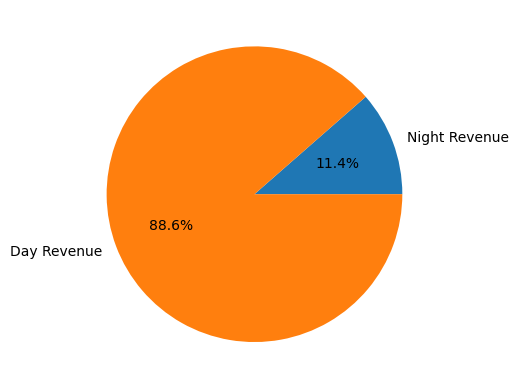

In [105]:
day_rides = sample_data2[ (sample_data2['tpep_pickup_datetime'].dt.time < pd.to_datetime('23:00:00').time()) & (sample_data2['tpep_pickup_datetime'].dt.time >= pd.to_datetime('05:00:00').time())]
# Filter for night hours (11 PM to 5 AM)
night_revenue = round(night_rides['total_amount'].sum(),2)
day_revenue =round(day_rides['total_amount'].sum(),2)

print("Revenue during night hours: $",night_revenue ,'\n',"Revenue during day hours: $",day_revenue)

plt.pie(x=[night_revenue,day_revenue],labels=['Night Revenue','Day Revenue'], autopct = '%1.1f%%')
plt.show()

##### Pricing Strategy

**3.2.9** For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.


In [106]:
# Analyse the fare per mile per passenger for different passenger counts
sample_data2[['passenger_count','total_amount','trip_distance']]

average_amount=pd.DataFrame(sample_data2.groupby('passenger_count')[['total_amount','trip_distance']].sum().reset_index())

average_amount['avg_fare_per_mile']= round(average_amount['total_amount']/average_amount['trip_distance'],2)

average_amount['avg_fare_per_mile_per_passenger']= average_amount['avg_fare_per_mile']/average_amount['passenger_count']

average_amount[['passenger_count','avg_fare_per_mile_per_passenger']]

,passenger_count,avg_fare_per_mile_per_passenger
0,1.0,8.350000
1,2.0,3.870000
2,3.0,2.640000
3,4.0,1.965000
4,5.0,1.676000
5,6.0,1.378333


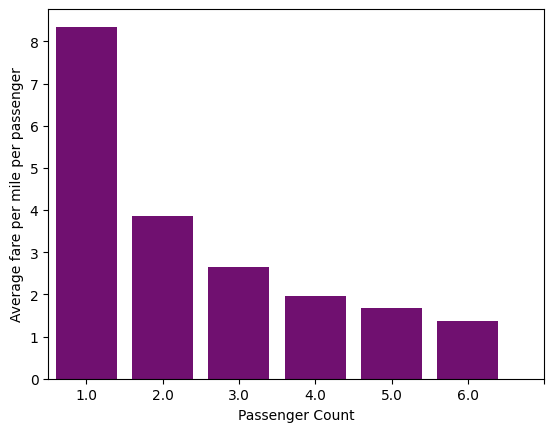

In [107]:
sns.barplot(x= average_amount['passenger_count'],y =average_amount['avg_fare_per_mile_per_passenger'],color = 'purple')
plt.xlabel('Passenger Count')
plt.ylabel('Average fare per mile per passenger')
plt.xticks(range(0,7))
plt.show()

**3.2.10** Find the average fare per mile by hours of the day and by days of the week


In [108]:
# Compare the average fare per mile for different days and for different times of the day
sample_data2['fare_per_mile'] = sample_data2['fare_amount'] / sample_data2['trip_distance']

avgfare_day_hour = sample_data2.pivot_table( values='fare_per_mile', index=sample_data2['tpep_pickup_datetime'].dt.day_name(),columns=sample_data2['tpep_pickup_datetime'].dt.hour,aggfunc='mean')

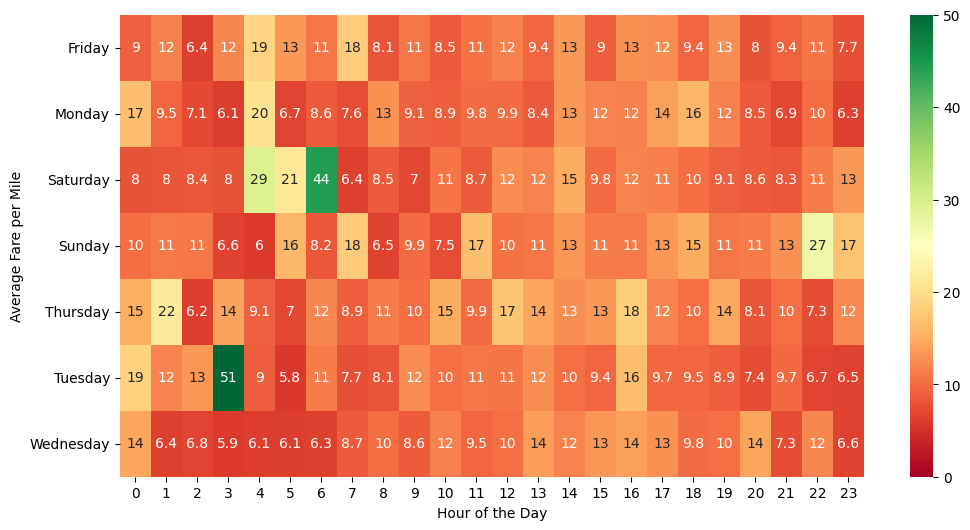

In [109]:
#avgfare_day_hour.plot(figsize=(12, 6), cmap='coolwarm')
plt.figure(figsize=(12, 6))
sns.heatmap(avgfare_day_hour,cmap='RdYlGn',annot=True,vmin=0, vmax=50)
#plt.title('Average Fare per Mile by Day and Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Fare per Mile')
plt.show()

**3.2.11** Analyse the average fare per mile for the different vendors for different hours of the day


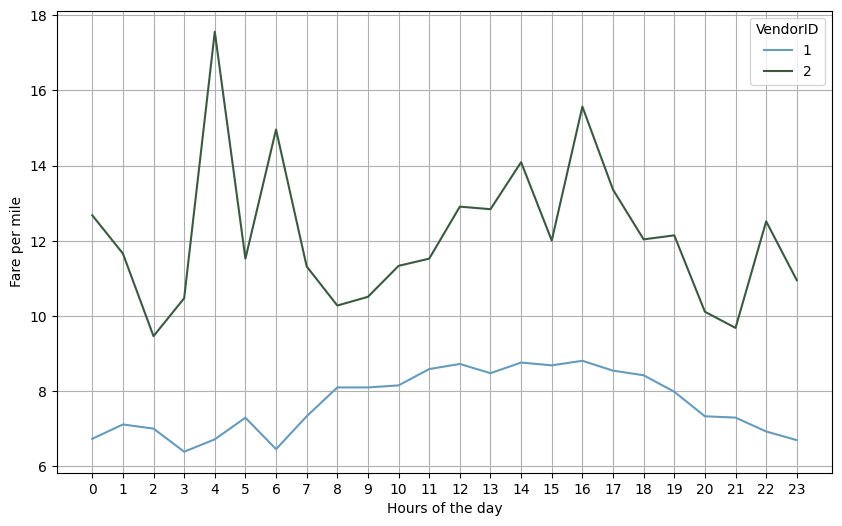

In [110]:
plt.figure(figsize=(10,6))
vendor_farepermile= pd.DataFrame(sample_data2.groupby(['VendorID',sample_data2.tpep_pickup_datetime.dt.hour])['fare_per_mile'].mean().reset_index())
sns.lineplot(data=vendor_farepermile, x= 'tpep_pickup_datetime' , y ='fare_per_mile', hue= 'VendorID',palette = ['#669bbc','#3a5a40'] )
plt.xlabel('Hours of the day')
plt.ylabel('Fare per mile')
plt.xticks(range(24))
plt.grid(True)
plt.show()

**3.2.12** Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [111]:
# Define distance tiers for the vendor pricing comparison.
sample_data2 = sample_data2.reset_index(drop=True)

sample_data2['distance_category'] = np.select(
    [sample_data2['trip_distance'] <= 2, sample_data2['trip_distance'] <= 5],
    ['Upto 2 miles', '2 to 5 miles'],
    default='More than 5 miles',
)

print(sample_data2['distance_category'].value_counts().to_string())


distance_category
Upto 2 miles         199333
2 to 5 miles         100176
More than 5 miles     63335


In [112]:
avg_distance_category = sample_data2.groupby(['VendorID','distance_category'])[['total_amount','trip_distance']].sum()

avg_distance_category['AvgFare']= avg_distance_category['total_amount']/avg_distance_category['trip_distance']

avg_distance_category

total_amount  trip_distance    AvgFare
VendorID distance_category                                        
1        2 to 5 miles          649237.62       72710.90   8.929027
         More than 5 miles     919009.65      162694.90   5.648669
         Upto 2 miles          885108.57       60806.90  14.556055
2        2 to 5 miles         2105091.01      229565.19   9.169905
         More than 5 miles    3341384.86      575485.89   5.806198
         Upto 2 miles         2546039.04      170886.23  14.899030

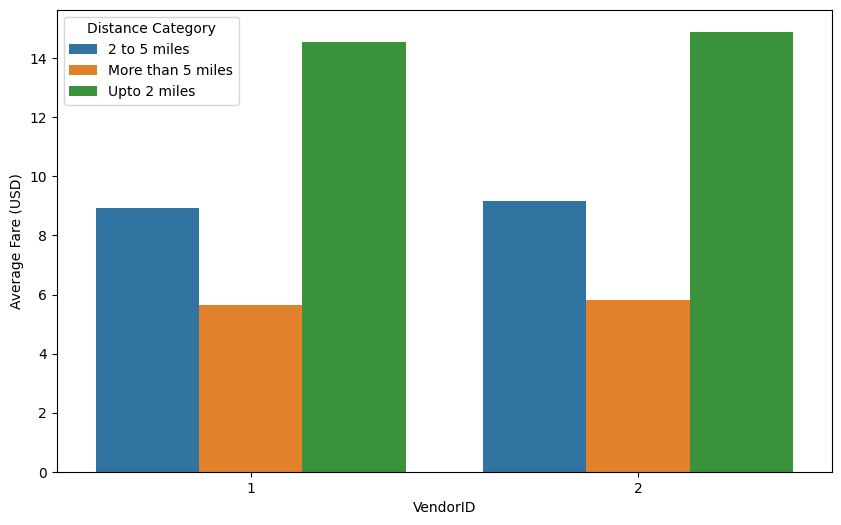

In [113]:
avg_distance_category.reset_index(inplace=True)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_distance_category, x='VendorID', y='AvgFare', hue='distance_category')

#plt.title('Average Fare by Distance Category for Each Vendor')
plt.xlabel('VendorID')
plt.ylabel('Average Fare (USD)')
plt.legend(title='Distance Category')

plt.show()

##### Customer Experience and Other Factors

**3.2.13** Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?


In [114]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
sample_data2['tip_percentages']= round(sample_data2['tip_amount']/sample_data2['total_amount'],4)*100
sample_data2.groupby('distance_category')['tip_percentages'].mean()

distance_category
2 to 5 miles         12.216336
More than 5 miles    11.289827
Upto 2 miles         12.157939
Name: tip_percentages, dtype: float64

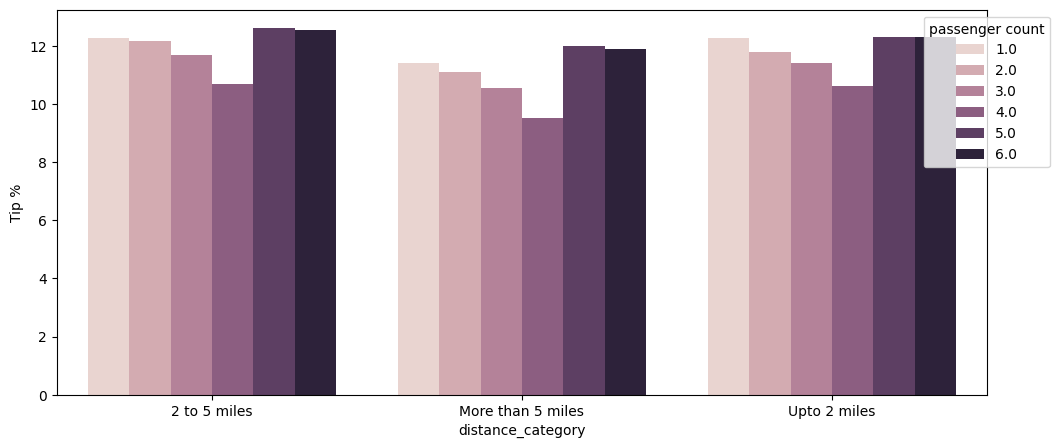

In [115]:
tip_percent_passenger= pd.DataFrame(sample_data2.groupby(['passenger_count','distance_category'])['tip_percentages'].mean().reset_index())

plt.figure(figsize=(12,5))
sns.barplot(data= tip_percent_passenger, x= 'distance_category', y ='tip_percentages', hue='passenger_count')
plt.ylabel('Tip %')
plt.legend(title='passenger count', loc='upper center', bbox_to_anchor=(1, 1))
plt.show()

In [116]:
#let's categorise hour of day - morning = 5 to 12 , afternoon 12-6, evening 18-24 , night- 00-5
sample_data2['hour']= sample_data2['tpep_pickup_datetime'].dt.hour

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

sample_data2['time_of_day'] = sample_data2['hour'].apply(time_of_day)

In [117]:
sample_data2.groupby(['time_of_day','distance_category'])['tip_percentages'].mean()

time_of_day  distance_category
Afternoon    2 to 5 miles         11.999284
             More than 5 miles    11.299579
             Upto 2 miles         11.991411
Evening      2 to 5 miles         12.682861
             More than 5 miles    11.670303
             Upto 2 miles         12.393726
Morning      2 to 5 miles         11.828360
             More than 5 miles    10.911489
             Upto 2 miles         12.143728
Night        2 to 5 miles         11.968014
             More than 5 miles    10.773597
             Upto 2 miles         12.001120
Name: tip_percentages, dtype: float64

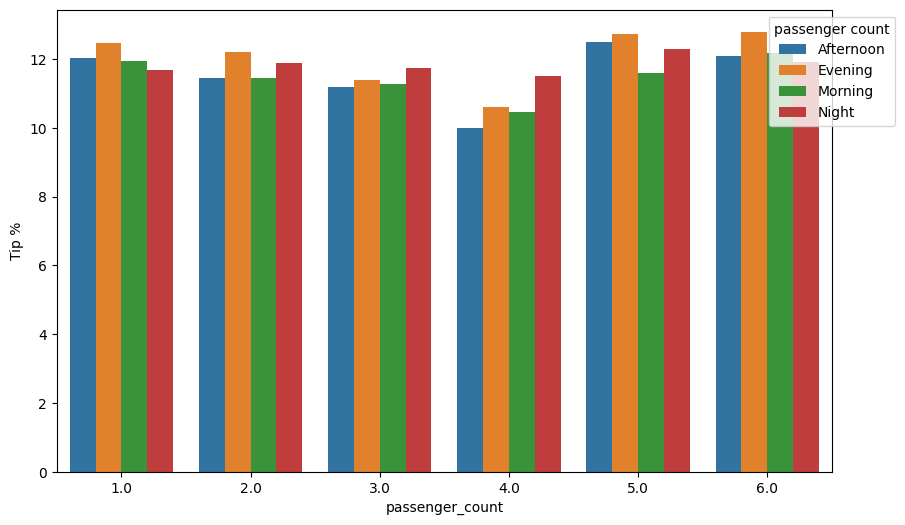

In [118]:
tip_passenger =pd.DataFrame(sample_data2.groupby(['passenger_count','time_of_day'])['tip_percentages'].mean().reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data=tip_passenger, x='passenger_count', y ='tip_percentages',hue='time_of_day')
plt.ylabel('Tip %')
plt.legend(title='passenger count', loc='upper center', bbox_to_anchor=(1, 1))
plt.show()

**3.2.14** Analyse the variation of passenger count across hours and days of the week.


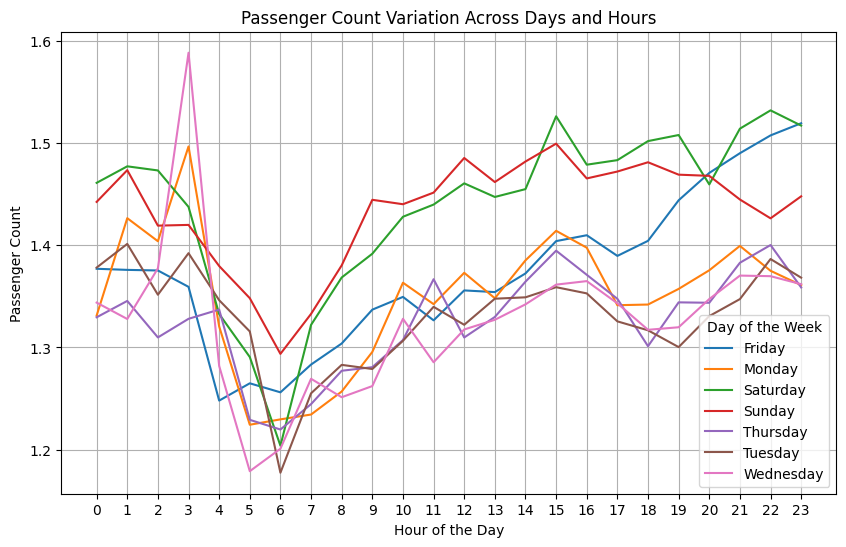

In [119]:
# See how passenger count varies across hours and days
sample_data2.groupby([ sample_data2['tpep_pickup_datetime'].dt.hour,sample_data2['tpep_pickup_datetime'].dt.day_name()])['passenger_count'].mean().unstack().plot(kind='line', figsize=(10, 6))
plt.title('Passenger Count Variation Across Days and Hours')
plt.xticks(sample_data2['tpep_pickup_datetime'].dt.hour.unique())
plt.xlabel('Hour of the Day')
plt.ylabel('Passenger Count')
plt.legend(title='Day of the Week')
plt.grid(True)
plt.show()

**3.2.15** Analyse the variation of passenger counts across zones


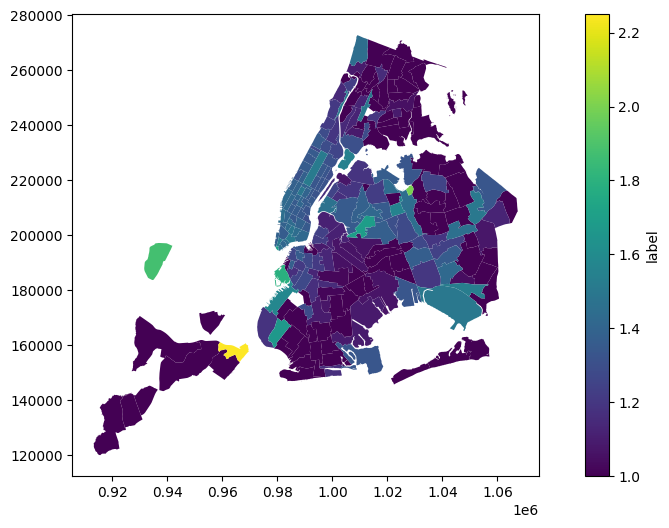

In [120]:
# How does passenger count vary across zones
zone_passenger_count=pd.DataFrame(sample_data2.groupby('zone')['passenger_count'].mean().reset_index())
zone2 = pd.merge(zones,zone_passenger_count,left_on='zone',right_on ='zone')

fig, ax = plt.subplots(1, 1, figsize = (12, 6))
zone2.sort_values(by='passenger_count').plot(column = 'passenger_count',ax=ax,legend=True,legend_kwds ={'label': "label", 'orientation': "vertical"} )
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** Analyse the pickup/dropoff zones or times when extra charges are applied more frequently


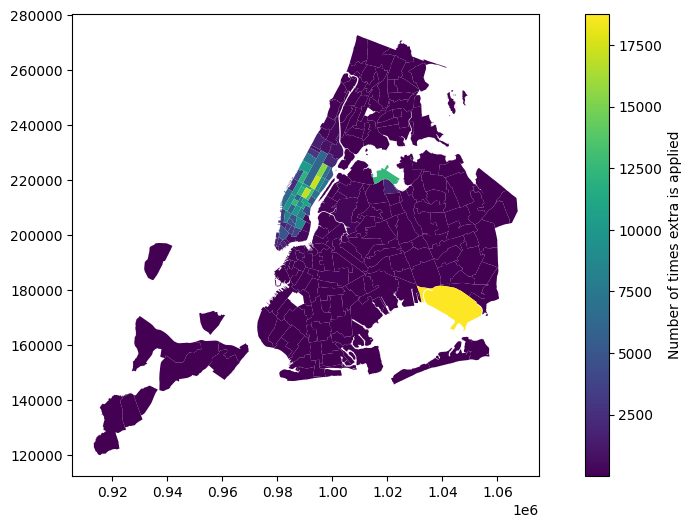

In [121]:
# How often is each surcharge applied?
sample_data2['extra_applied'] = 0
sample_data2['extra_applied']= sample_data2.apply(lambda x:1 if (x['extra']!= 0) | (x['improvement_surcharge']!=0) | (x['congestion_surcharge']!=0) else 0,axis=1)

zone_extra = pd.DataFrame(sample_data2.groupby('zone')['extra_applied'].sum().reset_index())
zone2 = pd.merge(zone2,zone_extra,left_on='zone',right_on ='zone')

fig, ax = plt.subplots(1, 1, figsize = (12, 6))

zone2.sort_values(by='extra_applied').plot(column = 'extra_applied',ax=ax,legend=True,legend_kwds ={'label': "Number of times extra is applied", 'orientation': "vertical"} )
plt.show()

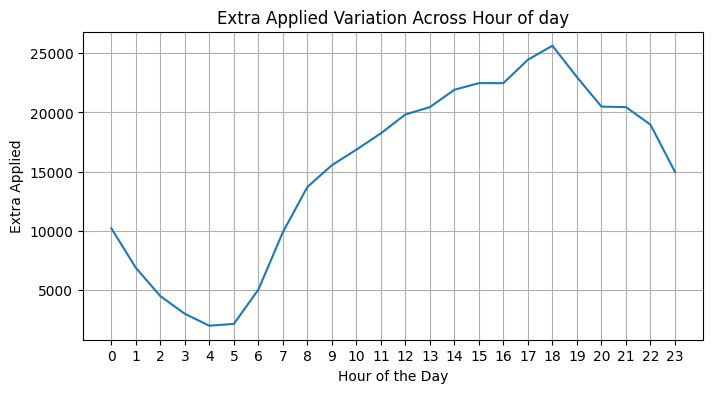

In [122]:
sample_data2.groupby(sample_data2['tpep_pickup_datetime'].dt.hour)['extra_applied'].sum().plot(kind='line', figsize=(8, 4))
plt.title('Extra Applied Variation Across Hour of day')
plt.xticks(sample_data2['tpep_pickup_datetime'].dt.hour.unique())
plt.xlabel('Hour of the Day')
plt.ylabel('Extra Applied')
plt.grid(True)
plt.show()

## **4** Conclusion


### **4.1** Final Insights and Recommendations
Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.


**4.1.1** Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies


* To improve demands of taxis in high-demand areas, the drop-offs at high pickup-drop-off ration zones could be accepted more frequently.
* Low pickup-drop-off ratio could also mean more drops than pick-ups. Offbeat places like Richmond hills or forest hills trips could be accepted more with reduced extra charges to increase demand at these places.
* During morning hours taxis can be deployed to more traffic areas such as zones near airports or central park or time square areas, to meet increase in demand during peak hours.

**4.1.2** Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.


* When observed the pickup and drops at different zones, spots like time square, central park, bay area and most important airports see most traffic and pickups.
* During evening hours the demand and traffic rises, hence more taxis can be placed at these locations to fulfil rise in demands
* Airports provide us long distance rides, and fare amount is strongly correlated to distance. Hence, a taxi booth or pickup zone could be established. 
* Weekends and Tuesdays are observed to get a greater number of bookings. In order to increase rides during other days, taxis could be deployed more in uptown areas.

**4.1.3** Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.


* In order to increase revenue during months of winter, average price for distance more than 5 miles can be increased, by $1 -$1.5 per mile, it can be checked to not apply surcharge amount upto certain distance to keep pricing comparable.
* Prices can be increased by 25% during peak hours and during weekends, as demand rises
* We observe lesser average fair price per mile during Friday evening hours.These can be increased by 10% to ensure increase in revenue.
* To improve night revenue factor, cabs could be deployed to areas where extra charges are applied more.
* Vendors have equal average fare prices, with price range of vendor 1 lesser than vendor 2. Vendor 1 can hence be deployed more at high pickup zones to ensure optimum pricing, meet demand and hence increase revenue.
* The low average rate per mile could be due to insufficient demand. Discount offers could be offered for longer distance rides to ensure rise in demand and thus increase pricing for the routes.


---

## 5 Exporting Data for the Dashboard

The interactive Dash application (`dashboard/app.py`) does not re-run this cleaning pipeline
on startup. Instead the cleaned trip table and the reprojected taxi-zone geometry are written
to `data/processed/` here, and the app loads those directly.


In [123]:
# Cleaned trip-level table for the dashboard.
# The geometry column from the zone merge is dropped - parquet cannot store shapely
# objects, and the app joins geometry back on LocationID from the GeoJSON below.
dashboard_cols = [
    "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "trip_duration", "speed",
    "PULocationID", "DOLocationID", "LocationID", "zone", "borough",
    "payment_type", "RatecodeID",
    "fare_amount", "tip_amount", "total_amount", "extra",
    "congestion_surcharge", "airport_fee", "extra_applied",
    "fare_per_mile", "tip_percentages", "distance_category", "hour", "time_of_day",
]

trips_export = sample_data2[[c for c in dashboard_cols if c in sample_data2.columns]].copy()
trips_export.to_parquet(PROCESSED_DIR / "trips_clean.parquet", index=False)

# Taxi-zone polygons reprojected to WGS84, which is what Plotly's map traces expect.
zones_geo = gpd.read_file(TAXI_ZONES_DIR / "taxi_zones.shp").to_crs(epsg=4326)
zones_geo[["LocationID", "zone", "borough", "geometry"]].to_file(
    PROCESSED_DIR / "taxi_zones.geojson", driver="GeoJSON"
)

print(f"trips_clean.parquet   {len(trips_export):,} rows, "
      f"{len(trips_export.columns)} columns")
print(f"taxi_zones.geojson    {len(zones_geo):,} zones")
print(f"Sampling fraction used: {SAMPLE_FRACTION} "
      f"(scale counts by {int(1 / SAMPLE_FRACTION)}x for population estimates)")


trips_clean.parquet   362,844 rows, 26 columns
taxi_zones.geojson    263 zones
Sampling fraction used: 0.01 (scale counts by 100x for population estimates)
